#**Pengaruh Konsumsi Kopi terhadap Keseimbangan Pola Tidur, Tingkat Stres, dan Kesehatan Individu**

Nama: Atha Rina Sarwahita  
NIM: 2509116047



#**Import Library**

In [123]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#**Memuat Dataset**

In [124]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [125]:
path = '/content/drive/MyDrive/praktikum AVD/synthetic_coffee_health_10000.csv'
gd = pd.read_csv(path)
gd

,ID,Age,Gender,Country,Coffee_Intake,Caffeine_mg,Sleep_Hours,Sleep_Quality,BMI,Heart_Rate,Stress_Level,Physical_Activity_Hours,Health_Issues,Occupation,Smoking,Alcohol_Consumption
0,1,40,Male,Germany,3.5,328.1,7.5,Good,24.9,78,Low,14.5,NaN,Other,0,0
1,2,33,Male,Germany,1.0,94.1,6.2,Good,20.0,67,Low,11.0,NaN,Service,0,0
2,3,42,Male,Brazil,5.3,503.7,5.9,Fair,22.7,59,Medium,11.2,Mild,Office,0,0
3,4,53,Male,Germany,2.6,249.2,7.3,Good,24.7,71,Low,6.6,Mild,Other,0,0
4,5,32,Female,Spain,3.1,298.0,5.3,Fair,24.1,76,Medium,8.5,Mild,Student,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,50,Female,Japan,2.1,199.8,6.0,Fair,30.5,50,Medium,10.1,Moderate,Healthcare,0,1
9996,9997,18,Female,UK,3.4,319.2,5.8,Fair,19.1,71,Medium,11.6,Mild,Service,0,0
9997,9998,26,Male,China,1.6,153.4,7.1,Good,25.1,66,Low,13.7,NaN,Student,1,1
9998,9999,40,Female,Finland,3.4,327.1,7.0,Good,19.3,80,Low,0.1,NaN,Student,0,0


#**Bussiness Understanding**

##Business Objective

Dataset ini berisi data mengenai kebiasaan konsumsi kopi serta kondisi kesehatan dan gaya hidup para responden dari 20 negara berbeda. Data ini menggambarkan bagaimana individu dari berbagai usia, negara, dan latar belakang pekerjaan mengonsumsi kopi serta bagaimana kebiasaan tersebut berkaitan dengan kualitas tidur, tingkat stres, detak jantung, dan kondisi kesehatan lainnya.

Peningkatan konsumsi kopi sering dilakukan untuk menjaga energi dan konsentrasi, terutama pada individu dengan aktivitas padat. Masalah utama yang dapat diangkat dari dataset ini adalah adanya kemungkinan bahwa konsumsi kopi dalam jumlah tertentu dapat memengaruhi kesehatan individu, terutama pada kualitas tidur dan tingkat stres. Selain itu, konsumsi kafein juga diduga memiliki hubungan dengan kondisi fisik seperti detak jantung dan indeks massa tubuh. Masalah lain yang muncul adalah belum adanya pemahaman yang jelas mengenai bagaimana faktor gaya hidup seperti aktivitas fisik, kebiasaan merokok, dan konsumsi alkohol dapat memperkuat atau justru mengurangi dampak konsumsi kopi terhadap kesehatan. Oleh karena itu, dataset ini perlu dianalisis untuk menemukan pola hubungan antara konsumsi kopi dan berbagai indikator kesehatan.


##Asses Situation

Dataset ini berisi 10.000 data responden yang menggambarkan kebiasaan minum kopi, pola tidur, dan kondisi kesehatan dari berbagai negara. Data ini mewakili responden dari sekitar 20 negara, sehingga bisa memberikan gambaran yang cukup luas tentang kebiasaan konsumsi kopi di berbagai tempat.

Jumlah responden yang banyak membuat dataset ini cukup kuat untuk dianalisis karena dapat menunjukkan pola konsumsi kopi secara umum. Selain itu, responden berasal dari berbagai usia dan latar belakang, sehingga hasil analisis bisa lebih beragam dan tidak hanya menggambarkan satu kelompok tertentu saja.

Namun, dataset ini juga memiliki beberapa tantangan. Salah satu tantangan yang terlihat adalah adanya nilai yang kosong pada beberapa atribut, khususnya pada data gangguan kesehatan.

##Analytic Goals

*   Menganalisis hubungan konsumsi kopi dengan kualitas tidur, tingkat
stres, dan kondisi kesehatan responden.
*   Mengidentifikasi faktor gaya hidup yang memengaruhi dampak konsumsi kopi terhadap kesehatan.
*   Menemukan pola konsumsi kopi yang berpotensi menimbulkan risiko kesehatan.
*   Menghasilkan insight yang dapat digunakan untuk memberikan rekomendasi pola konsumsi kopi yang lebih sehat.





##Project Plan


*   Memahami struktur dataset dan arti setiap variabel.
*   Membersihkan dan menyiapkan data agar siap dianalisis.
*   Melakukan eksplorasi data memahami distribusi dan pola data.
*   Menganalisis hubungan antar variabel.
*   Memvisualisasikan serta menginterpretasikan hasil analisis dan menyusun kesimpulan.

#**Data Understanding**

##Struktur Data (Informasi Lanjutan)

In [126]:
gd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       10000 non-null  int64  
 1   Age                      10000 non-null  int64  
 2   Gender                   10000 non-null  object 
 3   Country                  10000 non-null  object 
 4   Coffee_Intake            10000 non-null  float64
 5   Caffeine_mg              10000 non-null  float64
 6   Sleep_Hours              10000 non-null  float64
 7   Sleep_Quality            10000 non-null  object 
 8   BMI                      10000 non-null  float64
 9   Heart_Rate               10000 non-null  int64  
 10  Stress_Level             10000 non-null  object 
 11  Physical_Activity_Hours  10000 non-null  float64
 12  Health_Issues            4059 non-null   object 
 13  Occupation               10000 non-null  object 
 14  Smoking                

**Insight:**  
Dari hasil pengecekan struktur data, dataset ini terdiri dari 10.000 baris dan 16 variabel.  


*   5 kolom bertipe integer, sebagai berikut:
    *   ID
    *   Age
    *   Heart_Rate
    *   Stress_Level
    *   Smoking
    *   Alcohol_Consumption

*   5 kolom bertipe float
    *   Coffee_Intake
    *   Caffeine_mg
    *   Sleep_Hours
    *   BMI
    *   Physical_Activity_Hours

*   6 kolom bertipe object
    *   Gender
    *   Country
    *   Sleep_Quality
    *   Health_Issues
    *   Occupation


##Statistik Deskriptif

In [127]:
gd.describe()

,ID,Age,Coffee_Intake,Caffeine_mg,Sleep_Hours,BMI,Heart_Rate,Physical_Activity_Hours,Smoking,Alcohol_Consumption
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.00000,10000.000000
mean,5000.50000,34.949100,2.509230,238.411010,6.636220,23.986860,70.617800,7.48704,0.20040,0.300700
std,2886.89568,11.160939,1.450248,137.748815,1.222055,3.906411,9.822951,4.31518,0.40032,0.458585
min,1.00000,18.000000,0.000000,0.000000,3.000000,15.000000,50.000000,0.00000,0.00000,0.000000
25%,2500.75000,26.000000,1.500000,138.750000,5.800000,21.300000,64.000000,3.70000,0.00000,0.000000
50%,5000.50000,34.000000,2.500000,235.400000,6.600000,24.000000,71.000000,7.50000,0.00000,0.000000
75%,7500.25000,43.000000,3.500000,332.025000,7.500000,26.600000,77.000000,11.20000,0.00000,1.000000
max,10000.00000,80.000000,8.200000,780.300000,10.000000,38.200000,109.000000,15.00000,1.00000,1.000000


**Insight:**  


1.   Count (Kelengkapan Data)  
      Berdasarkan hasil statistik deskriptif, total data dalam dataset berjumlah 10.000 baris. Dan dapat terlihat juga bahwa kolom Health_Issues memiliki 5.941 data yang hilang, sedangkan seluruh kolom lainnya lengkap dengan 10.000 data.  
      
      Hal ini menunjukkan bahwa kolom Health_Issues memiliki tingkat missing value yang cukup tinggi, sehingga analisis terkait kondisi kesehatan perlu dilakukan dengan hati-hati agar tidak menghasilkan kesimpulan yang bias.


---


2.   Mean & Median (Distribusi Data)  


*   Kolom Coffee_Intake
    *   Mean: 2.509
    *   Median: 2.50  
    Kesimpulan: Distribusi konsumsi kopi relatif simetris. Tidak ada dominasi ekstrem. Mayoritas responden minum sekitar 2–3 cangkir per hari.
*   Kolom Caffeine_mg  
    *   Mean: 238.41 mg
    *   Median: 235.40 mg  
    Kesimpulan: Konsumsi kafein tergolong stabil. Tidak terlalu banyak extreme heavy caffeine users yang menggeser rata-rata.
*   Kolom Sleep_Hours  
    *   Mean: 6,63 jam
    *   Median: 6,60 jam  
        Kesimpulan: Durasi tidur cukup konsisten. Namun rata-rata masih di bawah rekomendasi ideal 7–8 jam, yang bisa jadi indikator pola hidup kurang optimal.
*   Kolom Physical_Activity_Hours  
    *   Mean: 7,48
    *   Median: 7,50  
        Kesimpulan: Aktivitas fisik cukup merata. Tidak ada skew ekstrem. Dataset menunjukkan populasi yang relatif aktif.
*   Kolom BMI  
    *   Mean: 15
    *   Median: 38,2  
Kesimpulan: Tidak terlihat adanya skew ekstrem yang menunjukkan dominasi kelompok obesitas atau underweight dalam dataset. Artinya, secara umum kondisi berat badan responden cukup stabil dan tidak berat sebelah.
    
*   Kolom Heart_Rate  
    *   Mean: 50 bpm
    *   Median: 109 bpm  
    Kesimpulan: Distribusi detak jantung sangat simetris dan stabil. Tidak ada indikasi kelompok dengan detak jantung sangat tinggi atau sangat rendah yang mendominasi.
---



3.   Minimal & Maximal  
*   Kolom Coffee_Intake
    *   Min: 0 cangkir
    *   Max: 8,20 cangkir  
    Kesimpulan: 8+ cangkir per hari termasuk kategori tinggi, tapi masih realistis. Tidak terlihat error input ekstrem seperti 50 cangkir.
*   Kolom Caffeine_mg  
    *   Min: 0 mg
    *   Max: 780.30 mg  
        Kesimpulan: 780.20 mg sudah sangat tinggi dan melewati batas aman harian (±400 mg). Ini kemungkinan heavy consumer. Secara logika masih mungkin, tapi secara kesehatan berisiko.

*   Kolom Sleep_Hours  
    *   Min: 3 jam
    *   Max: 10 jam  
        Kesimpulan: Kolom ini masih masuk akal, masih dalam rentang jam tidur normal.
*   Kolom Physical_Activity_Hours  
    *   Min: 0 jam
    *   Max: 15 jam  
        Kesimpulan: Kolom Physical_Activity_Hours memiliki rentang yang wajar dan tidak menunjukkan indikasi kesalahan input data.
*   Kolom BMI  
    *   Min: 15
    *   Max: 38,2  
        Kesimpulan: Range menunjukkan variasi dari underweight hingga obesitas. Kolom ini termasuk kolom realistis.

*   Kolom Heart_Rate  
    *   Min: 50 bpm
    *   Max: 109 bpm  
        Kesimpulan: Heart rate masih dalam range normal.


---


4.   Standar Deviasi
*   Kolom Coffee_Intake
    *   Std = 1,45  
    Kesimpulan: Konsumsi kopi tidak terlalu ekstrem.

*   Kolom Caffeine_mg
    *   Std = 137 mg  
    Kesimpulan: Variasi cukup besar, menunjukkan perbedaan signifikan antar individu.
*   Kolom Heart_Rate  
    *   Std = 9,82  
    Kesimpulan: Normal dan Stabil.
*   Kolom Physical_Activity_Hours  
    *   Std = 4,31  
    Kesimpulan: Variasi pada kolom ini cukup tinggi. Ada kelompok sangat aktif dan kelompok kurang aktif.





##Cek Tipe Data Pada Setiap Kolom

In [128]:
gd.dtypes

,0
ID,int64
Age,int64
Gender,object
Country,object
Coffee_Intake,float64
Caffeine_mg,float64
Sleep_Hours,float64
Sleep_Quality,object
BMI,float64
Heart_Rate,int64


**Insight:**  
Berdasarkan dari pengecekan tipe data,seluruh kolom pada dataset sudah tersimpan sesuai dengan karateristik nilainya. Seperti kolom yang berupa numerik menggunakan int dan float (untuk desimal), sedangkan kolom kategorikal menggunakan tipe object. Hal ini berarti tidak ada kesalahan seperti tipe data angka yang terbaca sebagai tulisan (object) ataupun sebaliknya.

##Cek Inconsistent Values Pada Setiap Kolom

**1. ID**

In [129]:
print(gd['ID'].unique())

[    1     2     3 ...  9998  9999 10000]


Kolom ID berjumlah 10.00 baris. Tidak ditemukan nilai kosong ataupun format penulisan yang aneh. Kolom ID dapat dibilang sebagai kolom konsisten.

**2. Age**

In [130]:
print(gd['Age'].unique())

[40 33 42 53 32 44 29 41 37 18 28 22 38 24 52 35 36 21 39 27 31 57 34 20
 19 43 26 47 30 46 51 25 45 64 48 61 23 50 67 80 62 60 56 54 49 59 58 71
 55 65 66 63 73 72 68 70 69 77 75]


Kolom age bertipe numerik dan tidak ada nilai aneh yang tidak sesuai dengan format. Dapat dilihat bahwa semua data umur masih berada dalam rentang usia wajar. Pada kolom ini tidak ditemukan inkonsistensi.

**3. Gender**

In [131]:
print(gd['Gender'].unique())

['Male' 'Female' 'Other']


Pada kolom gender bertipe object. Nilai kategori pada kolom ini adalah konsisten, tidak ditemukan penulisan format lain, seperti "male", "MALE", dan lain-lainnya.

**4. Country**

In [132]:
print(gd['Country'].unique())

['Germany' 'Brazil' 'Spain' 'Mexico' 'France' 'Canada' 'UK' 'Switzerland'
 'Netherlands' 'Italy' 'China' 'Japan' 'Belgium' 'Finland' 'Australia'
 'USA' 'Sweden' 'India' 'Norway' 'South Korea']


Pada kolom country, semua format data konsisten. Tidak ditemukan adanya kategori yang double karena perbedaan penulisan format.

**5. Coffee_Intake**

In [133]:
print(gd['Coffee_Intake'].unique())

[3.5 1.  5.3 2.6 3.1 3.4 2.7 4.5 1.7 4.  4.1 4.7 1.4 3.2 4.3 0.7 2.2 0.
 2.4 4.6 0.4 1.9 0.8 2.5 1.5 2.8 4.4 3.8 2.  3.3 2.1 3.6 1.6 1.1 0.9 4.9
 0.1 5.4 1.3 0.6 1.8 2.9 4.2 2.3 3.9 1.2 7.6 0.2 7.1 5.2 0.5 3.7 5.  6.2
 3.  4.8 5.1 7.3 5.8 5.9 6.1 5.5 5.7 6.4 0.3 5.6 6.7 6.  6.5 6.3 8.2 7.2
 7.  6.6 7.8 6.8 7.7 6.9]


Pada kolom Coffee Intake, semua data bertipe float (ditulis dalam bentuk desimal), kolom ini bersifat konsisten.

**6. Caffeine_mg**

In [134]:
print(gd['Caffeine_mg'].unique())

[328.1  94.1 503.7 ... 460.2 509.1  59.1]


Semua data pada kolom Caffein bertipe numerik. Tidak terdapat data yang ditulis negatif atau format campuran seperti "300mg". Semua data ditulis secara konsisten.

**7. Sleep_Hours**

In [135]:
print(gd['Sleep_Hours'].unique())

[ 7.5  6.2  5.9  7.3  5.3  6.4  7.8  5.5  7.1  8.1  6.5  6.9  6.6  6.8
  7.7  5.7  5.   6.1  6.   8.3  9.2  7.9  4.8  7.4  7.   7.2  5.8  9.4
  7.6  8.   5.4  8.2  6.3  4.5  9.6  5.2  4.7  4.6  8.7  4.9  9.8  6.7
  5.6  8.8  4.2  8.5 10.   8.4  9.3  9.5  3.8  8.6  4.3  5.1  8.9  9.
  3.9  4.1  9.1  4.   9.9  3.   3.5  3.7  3.1  3.6  4.4  9.7  3.4  3.3
  3.2]


Pada kolom Sleep_Hours tidak ditemukan adanya data yang berbeda secara format penulisan atau inkonsisten. Semua data konsisten.

**8. Sleep_Quality**

In [136]:
print(gd['Sleep_Quality'].unique())

['Good' 'Fair' 'Excellent' 'Poor']


Pada kolom Sleep_Quality tidak ditemukan adanya kategori data yang berbeda secara format penulisan atau inkonsisten. Semua data konsisten, yaitu 'Good', 'Fair', 'Excellent', dan 'Poor'.

**9. BMI**

In [137]:
print(gd['BMI'].unique())

[24.9 20.  22.7 24.7 24.1 27.  24.3 15.8 21.7 30.4 21.5 23.1 15.4 19.8
 21.1 31.7 24.  23.3 18.8 28.2 17.  23.4 21.6 15.  20.8 27.6 18.1 27.5
 32.7 22.1 21.2 35.8 27.8 26.4 25.4 24.4 24.5 30.5 24.6 20.2 21.4 18.9
 29.  18.2 20.9 25.5 28.  23.9 23.5 17.2 25.9 25.6 16.9 26.5 29.2 22.5
 30.3 22.2 17.8 22.8 17.1 21.8 22.  17.7 28.3 19.9 33.1 15.5 17.3 23.6
 28.4 26.3 28.8 23.  25.  29.1 22.4 25.3 27.2 19.3 23.7 26.6 24.2 19.4
 20.4 31.5 25.8 22.3 20.3 29.5 20.5 29.9 33.8 27.3 22.6 19.1 18.3 24.8
 20.1 26.  27.7 28.1 31.4 30.2 31.1 21.3 16.7 17.4 25.1 31.2 35.7 25.2
 19.6 23.8 16.1 31.3 29.4 33.3 32.3 18.6 18.  18.5 30.  30.8 18.7 26.8
 23.2 26.7 25.7 34.  30.1 17.6 22.9 21.9 29.3 20.7 26.2 28.5 27.4 16.2
 15.1 32.2 26.9 30.9 21.  19.2 33.9 27.9 32.5 30.7 29.6 19.5 18.4 35.5
 28.6 19.  26.1 28.7 20.6 29.7 17.9 31.9 31.8 15.7 29.8 27.1 28.9 30.6
 17.5 16.4 19.7 16.5 33.4 34.4 31.6 33.2 16.6 33.6 32.6 32.4 34.8 34.1
 34.9 16.8 16.3 15.3 36.7 35.  32.1 15.6 32.8 32.  15.9 33.  32.9 16.
 36.3 3

Pada kolom BMI tidak ditemukan adanya data yang inkonsisten. Semua data konsisten.

**10. Heart_Rate**

In [138]:
print(gd['Heart_Rate'].unique())

[ 78  67  59  71  76  82  58  62  60  69  66  80  77  83  56  70  72  63
  74  65  79  85  50  86  68  73  90  75  64  89 100  57  92  61  52  88
  84  55  87  81  91  96  93  95  53  51  54  94  98 106  97 109  99 102
 107 101 103 104]


Pada kolom Heart_Rate tidak ditemukan adanya data yang inkonsisten. Semua data konsisten.

**11. Stress_Level**

In [139]:
print(gd['Stress_Level'].unique())

['Low' 'Medium' 'High']


Pada kolom Stress_Level tidak ditemukan adanya kategori data yang berbeda format penulisan atau double. Semua kategori bersifat konsisten, yaitu 'Low', 'Medium', dan 'High'.

**12. Physical_Activity_Hours**

In [140]:
print(gd['Physical_Activity_Hours'].unique())

[14.5 11.  11.2  6.6  8.5  8.8  1.   0.7  2.2 11.9  8.4  8.9  5.2 13.
  3.2  4.7  4.9 14.4  7.8  5.5 13.5  2.9  6.9  3.4  8.2  2.  12.5  1.8
  2.6  4.1 12.2  3.1  3.3  9.8 12.4 10.5  8.1  5.4 10.4 10.3  9.5  3.5
 13.9 14.9  8.3  4.8 11.1  9.1  1.5 12.6 12.3 11.6  0.  11.5 11.3  7.9
  1.3  9.   0.4  4.4  2.3  7.6  5.8  4.6  8.6  9.2  1.7  7.5 13.1 13.2
 14.   9.7  3.6  3.8  2.5 10.9  6.7  7.   8.   1.9  0.5 13.4 12.7  8.7
  9.4 10.6  9.6 14.8  3.7  9.9  1.6  0.1  7.7 11.8  4.3  7.3 12.8 15.
  0.6 14.7  6.5  3.9 11.7  4.2 12.1  1.1  5.7 12.9  6.2 13.3  4.   7.2
  6.3 11.4 10.   2.7  0.2 10.7  7.1  0.3  5.1  5.9  6.8  6.   1.2 14.1
  2.1  6.4  1.4  2.8 13.8  9.3 13.6  0.8  3.  10.1 13.7  5.   2.4 10.8
  0.9  4.5 14.3  5.3 14.2 10.2  5.6 14.6 12.   7.4  6.1]


Pada kolom Physical_Activity_Hours tidak ditemukan adanya data yang berbeda format penulisan, data bersifat konsisten.

**13. Health_Issues**

In [141]:
print(gd['Health_Issues'].unique())

[nan 'Mild' 'Moderate' 'Severe']


Pada kolom Stress_Level tidak ditemukan adanya kategori data yang berbeda format penulisan atau double. Semua kategori bersifat konsisten, yaitu 'Mild', 'Moderate', dan 'Severe'. Namun pada kolom ini terdapat data yang hilang (nan).

**14. Occupation**

In [142]:
print(gd['Occupation'].unique())

['Other' 'Service' 'Office' 'Student' 'Healthcare']


Pada kolom Stress_Level tidak ditemukan adanya kategori data yang berbeda format penulisan atau double. Semua kategori bersifat konsisten, yaitu 'Other', 'Service', 'Office', 'Student', dan 'Healthcare'.

**15. Smoking**

In [143]:
print(gd['Smoking'].unique())

[0 1]


Pada kolom Smoking, data di kolom ini berupa angka biner, yaitu 0 dan 1. Jadi tidak ada data yang tidak konsisten.

**16. Alcohol_Consumption**

In [144]:
print(gd['Alcohol_Consumption'].unique())

[0 1]


Sama seperti kolom Smoking, pada kolom Alcohol_Consumption data di kolom ini berupa angka biner, yaitu 0 dan 1. Jadi tidak ada data yang tidak konsisten.

##Cek Missing Values

In [145]:
pd.DataFrame(gd.isna().sum() / len(gd) * 100, columns=['Null Ratio in %'])

,Null Ratio in %
ID,0.00
Age,0.00
Gender,0.00
Country,0.00
Coffee_Intake,0.00
Caffeine_mg,0.00
Sleep_Hours,0.00
Sleep_Quality,0.00
BMI,0.00
Heart_Rate,0.00


**Insight:**  
Dari total 10.000 baris dan 16 kolom data, dapat disimpulkan bahwa 15 dari 16 kolom memiliki data penuh (10.000 baris). Kecuali kolom Health_Issues yang memiliki tingkat missing value yang sangat tinggi, yaitu 59.41%.  
Dataset ini sangat kuat dan lengkap untuk analisis konsumsi kopi, tidur, stres, dan aktivitas fisik. Namun untuk analisis yang berkaitan dengan kondisi kesehatan, perlu dilakukan penanganan pada missing value terlebih dahulu agar tidak menghasilkan kesimpulan yang bias atau tidak akurat.

##Cek Duplicated Values

In [146]:
gd[gd.duplicated()]

,ID,Age,Gender,Country,Coffee_Intake,Caffeine_mg,Sleep_Hours,Sleep_Quality,BMI,Heart_Rate,Stress_Level,Physical_Activity_Hours,Health_Issues,Occupation,Smoking,Alcohol_Consumption


**Insight:**  
Berdasarkan hasil pengecekan, tidak ditemukan data yang duplikat dalam dataset. Hal ini menunjukkan bahwa setiap baris merepresentasikan satu responden yang unik dan tidak ada pengulangan data yang sama secara keseluruhan.

##Cek Outliers

In [147]:
results = []

# Exclude 'object' type columns for outlier detection using IQR
cols_numeric = gd.select_dtypes(include=['float64', 'int64']).columns

for col in cols_numeric: # Iterate only over numeric columns
  q1 = gd[col].quantile(0.25)
  q3 = gd[col].quantile(0.75)
  iqr = q3 - q1
  lower_bound = q1 - 1.5*iqr
  upper_bound = q3 + 1.5*iqr
  outliers = gd[(gd[col] < lower_bound) | (gd[col] > upper_bound)]
  percent_outliers = (len(outliers)/len(gd))*100
  results.append({'Kolom': col, 'Persentase Outliers': percent_outliers})

# Dataframe dari list hasil
results_gd = pd.DataFrame(results)
results_gd.set_index('Kolom', inplace=True)
results_gd = results_gd.rename_axis(None, axis=0).rename_axis('Kolom', axis=1)

# Tampilkan dataframe
display(results_gd)

Kolom,Persentase Outliers
ID,0.00
Age,0.25
Coffee_Intake,0.39
Caffeine_mg,0.39
Sleep_Hours,0.26
BMI,0.40
Heart_Rate,0.50
Physical_Activity_Hours,0.00
Smoking,20.04
Alcohol_Consumption,0.00


Berdasarkan kolom persentase outliers di atas, dapat diperoleh bahwa:  
*   ID   
Pada kolom ID tidak ada outlier, persentase menunjukkan angka **0.00%**.

*   Age  
Pada kolom age, terdapat **0.25%** outlier. Hanya ada kemungkinann sedikit data umur yang di luar rentang normal, seperti terlalu tua atau terlalu muda. Namun, jumlahnya sangat sedikit dan tidak signifikan.  

*   Coffee_Intake  
Persentase outlier Coffee_Intake menunjukkan angka **0.39%**. Hal ini dapat terjadi karena kemungkinan pada data, terdapat responden yang meminum kopi dalam jumlah yang banyak.  

*   Caffeine_mg  
Sama hal nya dengan Coffee_Intake, outlier pada kolom Caffein_mg adalah **0.39%**. Ini dapat terjadi karena pada data terdapat individu yang mengonsumsi cafein terlalu tinggi.  

*   Sleep_Hours  
Pada Sleep_Hours menunjukkan adanya outlier sebanyak **0.26%**. Hal ini berarti terdapat sebagian besar responden memiliki jam tidur dalam rentang yang umum, dan ada sedikit responden yang memiliki jam tidur sangat sedikit atau sangat banyak.
*   BMI  
Persentase outlier pada BMI adalah **0.40%**, ini berarti terdapat sedikit responden yang memiliki indeks masa tubuh yang sangat rendah (underweight) atau sangat tinggi (obese), namun jumlahnya sangat kecil.
*   Physical_Activity_Hours  
Tidak ada oulier pada jam aktivitas fisik, persentase menunjukkan angka **0.00%**. Ini berarti data aktivitas fisik sangat konsisten dan tidak ada nilai ekstrem.
*   Smoking  
Persentase oulier yang tinggi berada pada kolom Smoking, yaitu sebesar **20.04%**. Pada kolom ini, tidak ada nilai ekstrem, tetapi lebih kepada sifat data biner (0 atau 1). Angka ini menunjukkan proporsi responden yang merokok, ini bukanlah data yang perlu ditangani lebih lanjut.
*   Alcohol_Consumption  
Sama hal nya dengan 'Smoking', kolom ini juga biner (0 atau 1) dan tidak menunjukkan outlier, yang berarti tidak ada masalah dengan kolom ini **(0.00%)**.




#**Eksplorasi Data (EDA)**

##Comparison (Perbandingan)

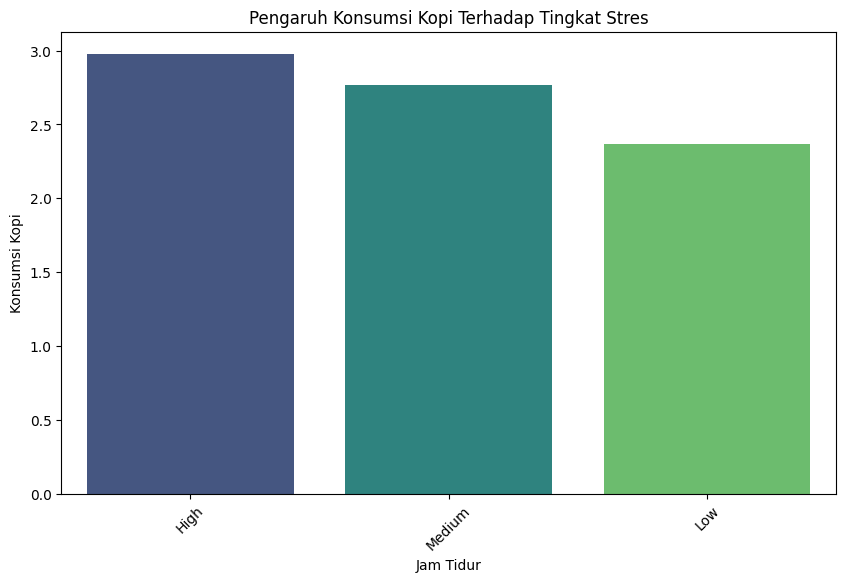

In [148]:
cofee_stress = gd.groupby('Stress_Level')['Coffee_Intake'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=cofee_stress.index, y=cofee_stress.values, palette='viridis', hue=cofee_stress.index, legend=False)
plt.title('Pengaruh Konsumsi Kopi Terhadap Tingkat Stres')
plt.xlabel('Jam Tidur')
plt.ylabel('Konsumsi Kopi')
plt.xticks(rotation=45)
plt.show()

**Insight:**  

Berdasarkan visualisasi rata-rata konsumsi kopi pada setiap tingkat stres, terlihat adanya pola peningkatan konsumsi kopi seiring dengan meningkatnya tingkat stres. Kelompok dengan tingkat stres tinggi menunjukkan rata-rata konsumsi kopi tertinggi dibandingkan kelompok stres sedang dan rendah.

Ini mengindikasikan adanya kecenderungan bahwa individu dengan tingkat stres lebih tinggi mengonsumsi kopi dalam jumlah yang lebih banyak. Hal ini dapat diasumsikan sebagai upaya untuk meningkatkan energi atau konsentrasi. Namun, dari grafik ini saja kita belum bisa memastikan apakah stres membuat orang minum lebih banyak kopi, atau justru kebiasaan minum kopi yang memengaruhi tingkat stres.  

Alasan saya memilih bar chart untuk membandingkan adalah karena grafik ini paling efektif menampilkan perbedaan nilai antar kategori. Dengan bar chart, perbedaan tinggi-rendah antar kelompok terlihat jelas dan mudah dianalisis.  

##Composition (Komposisi)

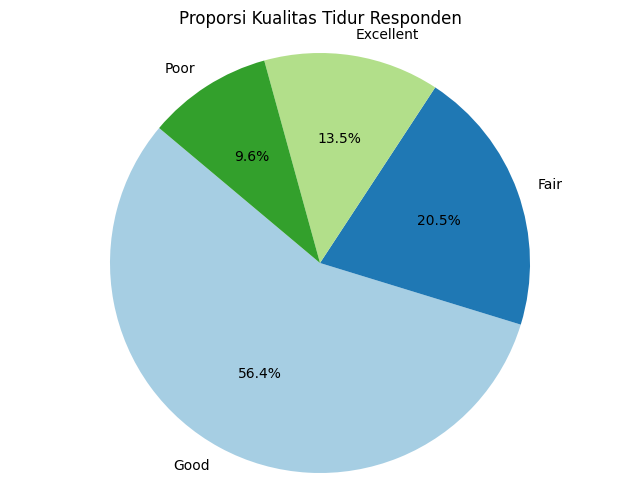

In [149]:
sleep_quality = gd['Sleep_Quality'].value_counts()
sleep_quality_resp = sleep_quality.head(4)

plt.figure(figsize=(8, 6))
sleep_quality_resp.plot(kind='pie', autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired.colors)
plt.title('Proporsi Kualitas Tidur Responden')
plt.ylabel('')
plt.axis('equal')
plt.show()

**Insight:**  
Berdasarkan diagram pie, mayoritas responden memiliki kualitas tidur dalam kategori Good sebanyak **56,4%**. Sementara itu, **20,5%** responden berada pada kategori Fair, **13,5%** pada kategori Excellent, dan **9,6%** pada kategori Poor.

Distribusi ini menunjukkan bahwa sebagian besar responden memiliki kualitas tidur yang cukup baik, namun proporsi kualitas tidur yang sangat optimal (Excellent) masih relatif kecil. Selain itu, masih terdapat hampir 10% responden dengan kualitas tidur buruk, yang dapat menjadi perhatian dalam analisis lebih lanjut terkait faktor kesehatan atau gaya hidup.  

Alasan saya menggunakan pie chart untuk menunjukkan proporsi kualitas tidur responden adalah karena grafik ini menampilkan pembagian kategori sebagai bagian dari keseluruhan. Visualisasi ini memudahkan identifikasi kategori yang paling dominan dalam suatu data.

##Distribution (Distribusi)

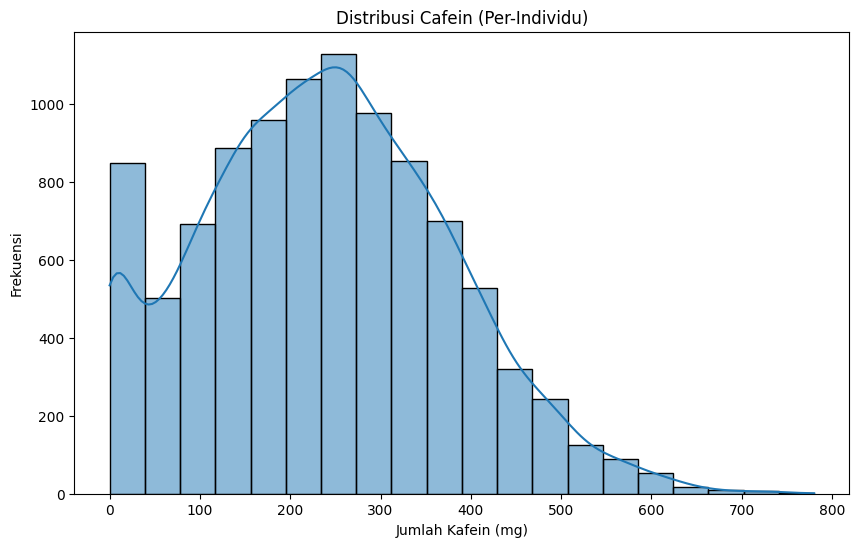

In [150]:
plt.figure(figsize=(10, 6))
sns.histplot(gd['Caffeine_mg'], bins=20, kde=True)
plt.title('Distribusi Cafein (Per-Individu)')
plt.xlabel('Jumlah Kafein (mg)')
plt.ylabel('Frekuensi')
plt.show()

**Insight:**  
Distribusi konsumsi kafein menunjukkan bahwa mayoritas responden berada pada rentang konsumsi sedang, dengan puncak frekuensi di sekitar 200–300 mg per individu. Distribusi terlihat sedikit condong ke kanan, yang mengindikasikan adanya sebagian kecil responden dengan konsumsi kafein yang jauh lebih tinggi dibandingkan rata-rata.

Saya memilih menggunakan untuk menampilkan distribusi konsumsi kafein karena data bersifat numerik. Grafik ini membantu melihat pola persebaran, konsentrasi nilai, serta kecenderungan distribusi seperti kemiringan data.

##Relationship (Hubungan)

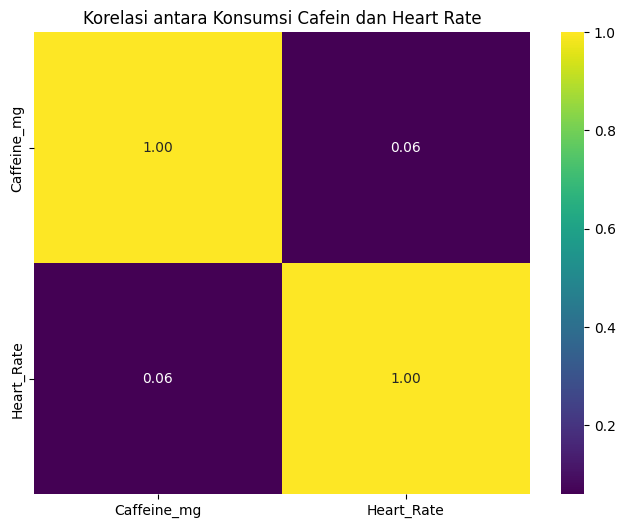

In [151]:
plt.figure(figsize=(8, 6))
sns.heatmap(data=gd[['Caffeine_mg', 'Heart_Rate']].corr(),
            annot=True,
            cmap='viridis',
            fmt='.2f')
plt.title('Korelasi antara Konsumsi Cafein dan Heart Rate')
plt.show()

**Insigth:**  
Hasil analisis korelasi menunjukkan nilai sebesar 0.06 antara konsumsi kafein dan denyut jantung. Nilai ini sangat mendekati nol, yang berarti hubungan antara kedua variabel tersebut sangat lemah. Dengan kata lain, dalam dataset ini peningkatan konsumsi kafein tidak menunjukkan perubahan denyut jantung yang konsisten atau signifikan.  

Alasan saya menggunakan heatmap untuk korelasi adalah karena heatmap dapat menunjukkan kekuatan hubungan antara konsumsi kafein dan denyut jantung secara visual. Intensitas warna memudahkan pembaca memahami apakah hubungan antar variabel kuat, lemah, atau hampir tidak ada. Selain intensitas warna, angka yang ditampilkan di dalam sel memperjelas tingkat hubungan tersebut, misalnya nilai mendekati 1 atau -1 menunjukkan hubungan kuat, sedangkan nilai mendekati 0 menunjukkan hubungan yang sangat lemah atau hampir tidak ada. Dengan kombinasi warna dan angka, interpretasi hubungan antar variabel menjadi lebih akurat dan informatif.

# **Data Preparation**

## **Data Cleaning**

###**Tipe Data**

Tipe data pada *dataset* ini sudah benar, tidak ada tipe data yang perlu diubah.

### **Inconsistent Values**

Tidak ditemukan adanya *inconsistent values* pada dataset ini. Semua kolom sudah dengan penulisan format yang konsisten.

### **Missing Values**

**Penanganan Missing Value**

In [152]:
gd['Health_Issues'] = gd['Health_Issues'].fillna('None')

Di sini saya menangani *missing value* dengan perintah imputasi kolom menggunakan "None", karena *missing value* yang terdapat pada kolom Health Issues bermakna tidak ada masalah kesehatan.

**Hasil Penanganan Missing Value**

In [153]:
pd.DataFrame(gd.isna().sum() / len(gd) * 100, columns=['Null Ratio in %'])

,Null Ratio in %
ID,0.0
Age,0.0
Gender,0.0
Country,0.0
Coffee_Intake,0.0
Caffeine_mg,0.0
Sleep_Hours,0.0
Sleep_Quality,0.0
BMI,0.0
Heart_Rate,0.0


Dapat terlihat di atas bahwa *missing value* sudah berhasil ditangani.

### **Duplicated Values**

Tidak ada *duplicated values* pada *dataset* ini.

### **Outliers**

Terdapat 7 kolom yang mengandung outliers, yaitu kolom Age, Coffee_Intake, Caffeine_mg, Sleep_Hours, BMI, Heart_Rate, dan Smoking.  




*   Pada kolom Age, terdapat **0.25%** nilai ekstrem. Setelah saya cek, nilai ekstrem tersebut masih di angka normal dan wajar umur manusia, namun memang di atas IQR. Menurut saya outlier pada kolom age tidak perlu ditangani.  
*   Pada kolom Coffee_Intake dan Caffeine_mg, terdapat **0.39%** outlier. Nilai ekstrem ini tidak perlu ditangani. Alasannya adalah karena memang ada heavy coffee drinker, konsumsi cafein dalam skala tinggi memang ada, bukan karena kesalahan pada input data. Kolom ini tidak perlu ditangani.


*   Pada kolom Sleep_Hours, terdapat **0.26%** outlier. Nilai ekstrem ini tidak terlalu mengganggu analisis dikarenakan nilai ekstrem rendah tersebut tidak terlalu jauh dari batas bawah quartil, sehingga kolom ini tidak perlu ditangani.
*   Pada kolom BMI, terdapat **0.40%**. Nilai yang termasuk ekstrem masih dalam klasifikasi medis dan secara real terdapat individu dengan angka BMI tersebut. Kolom ini tidak perlu diimputasi.


*   Pada kolom Heart_Rate, terdapat **0.50%**. Nilai yang termasuk ekstrem masih masuk akal dan nilai ekstrem tersebut dapat menjadi landasan analisis lanjutan yang berkaitan dengan pengaruh banyaknya konsumsi kopi.
*   Pada kolom smoking, kolom ini merupakan kolom yang berisikan angka biner (0 dan 1). Tercatat bahwa terdapat **20.04%** outlier, namun angka tersebut tidak menjadi masalah karena tidak ada yang salah pada kolom ini. Hanya saja, analisis outlier menggunakan metode IQR tidak cocok pada kolom yang berisikan angka biner. Kolom ini tidak perlu ditangani.






## **Data Construction**

In [154]:
def categorize_caffeine(mg):
    if mg <= 100:
        return "Low"
    elif 100 < mg <= 400:
        return "Moderate"
    else:
        return "High"

gd["Caffeine_Level"] = gd["Caffeine_mg"].apply(categorize_caffeine)

Pada *data construction*, saya menambahkan kolom Caffeine_Level. Ini dilakukan supaya data konsumsi kafein lebih mudah dipahami dan dibandingkan. Angka dalam miligram seperti 250 atau 420 memang jelas, tapi sulit langsung terlihat apakah itu termasuk tingkat konsumsi rendah atau tinggi.  
Dengan membaginya menjadi Low, Moderate, dan High, saya bisa lebih mudah melihat perbedaan antar kelompok. Batas 400 mg digunakan karena itu merupakan batas konsumsi harian yang umum dianggap aman, sehingga pembagian kategori ini punya dasar yang jelas. Kolom ini membantu analisis jadi lebih terstruktur dan mudah dijelaskan tanpa menghilangkan data aslinya.

## **Data Reduction**

In [155]:
gd = gd.drop('ID', axis=1)
gd = gd.drop('Country', axis=1)
gd = gd.drop('Occupation', axis=1)

Pada *data reduction*, saya menghapus 3 kolom yang menurut saya tidak relevan pada tujuan analisis saya. Saya menghapus kolom ID, Country, dan Occupation. Alasan saya menghapus kolom ID adalah karena kolom ID tidak diperlukan pada analisis saya, kolom ID hanyalah kolom yang menampilkan urutan 1-10.000. Alasan saya menghapus kolom country dan occupation adalah karena 2 kolom ini juga tidak diperlukan pada tujuan analisis saya, yaitu hubungan konsumsi kafein dan indikator kesehatan

#**Menyimpan Dataset Bersih**

In [156]:
gd.to_csv('[Bersih] synthetic_coffee_health_10000.csv', index=False)

#**Matplotplib & Seaborn**

##**Bar Chart**

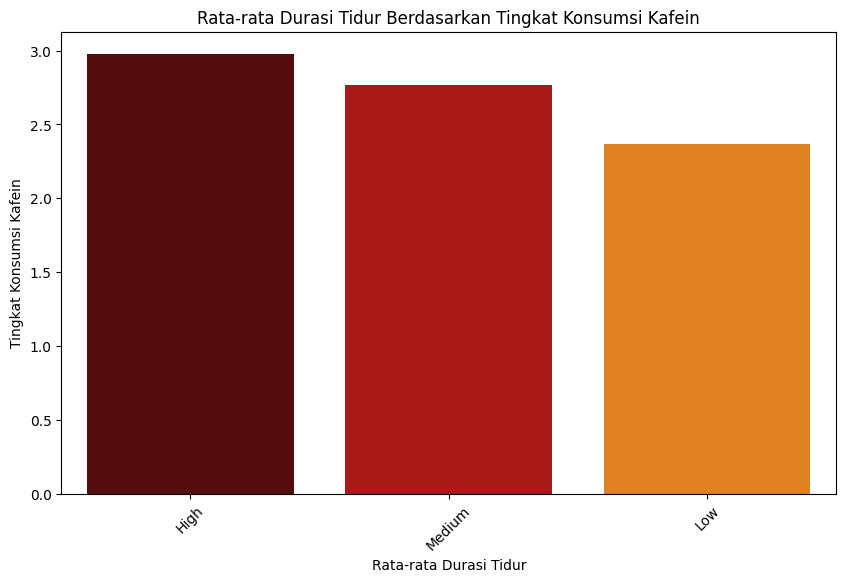

In [157]:
sleep_stress = gd.groupby('Caffeine_Level')['Sleep_Hours'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=cofee_stress.index, y=cofee_stress.values, palette='gist_heat', hue=cofee_stress.index, legend=False)
plt.title('Rata-rata Durasi Tidur Berdasarkan Tingkat Konsumsi Kafein')
plt.xlabel('Rata-rata Durasi Tidur')
plt.ylabel('Tingkat Konsumsi Kafein')
plt.xticks(rotation=45)
plt.show()

###**Insight**  
Barchart di atas menunjukkan tren penurunan durasi tidur seiring dengan meningkatnya tingkat konsumsi kafein. Kelompok dengan tingkat konsumsi Low memiliki durasi tidur paling lama, yaitu hampir mencapai 7 jam, sedangkan kelompok High memiliki durasi tidur terendah di angka sekitar 6 jam. Perbedaan ini mengonfirmasi bahwa asupan kafein yang lebih tinggi berkorelasi dengan berkurangnya waktu istirahat harian.

###**Action**  
Langkah yang bisa diambil adalah membatasi minuman berkafein untuk membantu kelompok High dan Moderate mendapatkan durasi tidur yang lebih panjang. Bisa juga dengan mengganti jatah kopi di sore hari dengan minuman alternatif bebas kafein seperti jus buah atau air mineral agar kualitas istirahat malam tetap terjaga. Selain itu, fokuslah untuk menstabilkan jadwal tidur di angka minimal 7 jam bagi semua kelompok sebelum mencoba melakukan perubahan gaya hidup lain.

##**Pie Chart**

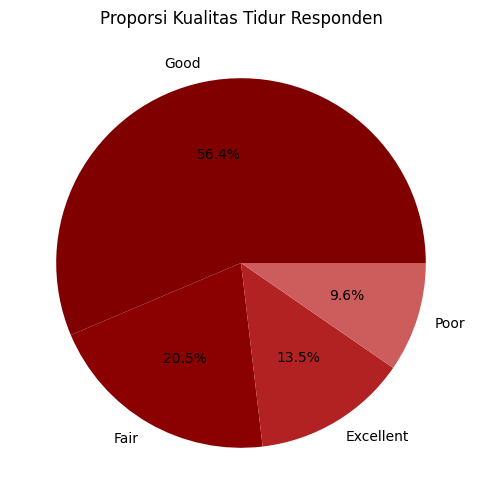

In [158]:
plt.figure(figsize=(10, 6)) # ukuran
plt.pie(gd['Sleep_Quality'].value_counts(), labels=gd['Sleep_Quality'].value_counts().index, autopct='%1.1f%%', colors=['maroon', 'darkred', 'firebrick', 'indianred']) # colors (warna)
plt.title('Proporsi Kualitas Tidur Responden') # Judul
plt.show()

###**Insight**  
Berdasarkan visualisasi proporsi kualitas tidur responden di atas, dapat disimpulkan bahwa mayoritas responden sudah memiliki pola tidur yang cukup sehat, di mana kategori Good mendominasi dengan angka **56,4%**. Jika digabungkan dengan kategori Excellent sebesar **13,5%**, maka terdapat sekitar **69,9%** responden yang berada pada level kualitas tidur memuaskan. Hal ini mengindikasikan bahwa sebagian besar responden kemungkinan besar memiliki produktivitas dan kondisi kesehatan yang stabil berkat kualitas tidur yang terjaga dengan baik. Beberapa responden memiliki kualitas tidur kurang optimal, yaitu gabungan kategori Fair **(20,5%)** dan Poor **(9,6%)** yang mencapai total **30,1%**. Angka ini cukup signifikan karena menunjukkan hampir sepertiga responden berisiko mengalami penurunan kesehatan atau performa akibat pola tidur yang buruk.

###**Action**  
Tindakan yang diperlukan adalah menerapkan kebijakan disiplin diri sendiri, seperti membatasi penggunaan layar 30 menit sebelum tidur untuk menciptakan lingkungan istirahat yang lebih tenang dan gelap. Kondisi ini juga menunjukkan perlunya upaya untuk meningkatkan kebiasaan tidur yang lebih teratur, seperti mengatur jadwal tidur yang konsisten serta mengurangi konsumsi kafein berlebihan terutama pada malam hari agar kualitas tidur responden dapat meningkat.

##**Line Chart**

Saya tidak memakai line chart dikarenakan pada dataset saya tidak memiliki kolom tanggal yang relevan untuk digunakan pada line chart.

##**Histogram**

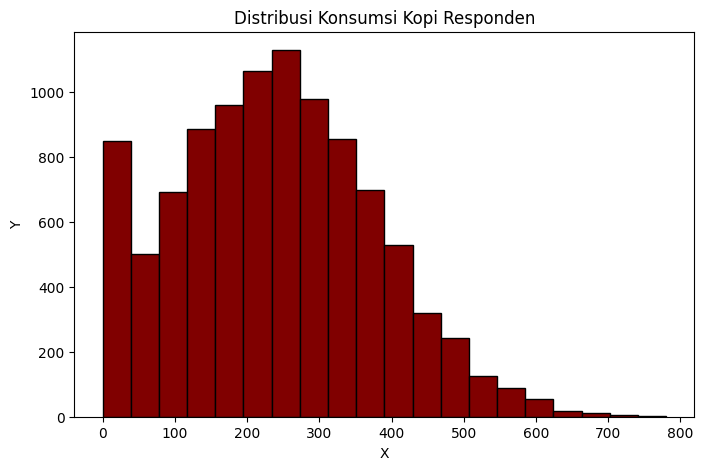

In [159]:
plt.figure(figsize=(8, 5))
plt.hist(gd['Caffeine_mg'], bins=20, color='maroon', edgecolor='black')
plt.title('Distribusi Konsumsi Kopi Responden')
plt.xlabel('X')
plt.ylabel('Y')
plt.show()

###**Insight**

Histogram di atas menunjukkan bahwa mayoritas responden mengonsumsi kafein dalam rentang 200 mg hingga 300 mg, dapat terlihat dari puncak tertinggi pada histogram tersebut. Distribusi data cenderung ke arah kanan (right skewed), yang berarti terdapat sebagian kecil kelompok responden yang mengonsumsi kafein dalam jumlah sangat tinggi hingga mencapai 600 mg sampai 800 mg. Selain itu, terdapat lonjakan frekuensi yang cukup signifikan pada angka mendekati 0 mg, menunjukkan adanya kelompok responden yang membatasi atau hampir tidak mengonsumsi kafein sama sekali dalam keseharian mereka.

###**Action**  

Memberikan edukasi khusus mengenai batas aman konsumsi kafein harian, yang biasanya sekitar 400 mg untuk orang dewasa (terutama yang mengonsumsi pada angka 600-800 mg) guna mencegah risiko kesehatan seperti gangguan kecemasan atau masalah tidur. Selain itu, bagi mereka yang mengonsumsi kafein di level moderat (200-300 mg), disarankan untuk menjaga waktu konsumsi agar tidak terlalu dekat dengan jam tidur guna mempertahankan kualitas tidur yang sudah baik.

##**BoxPlot**

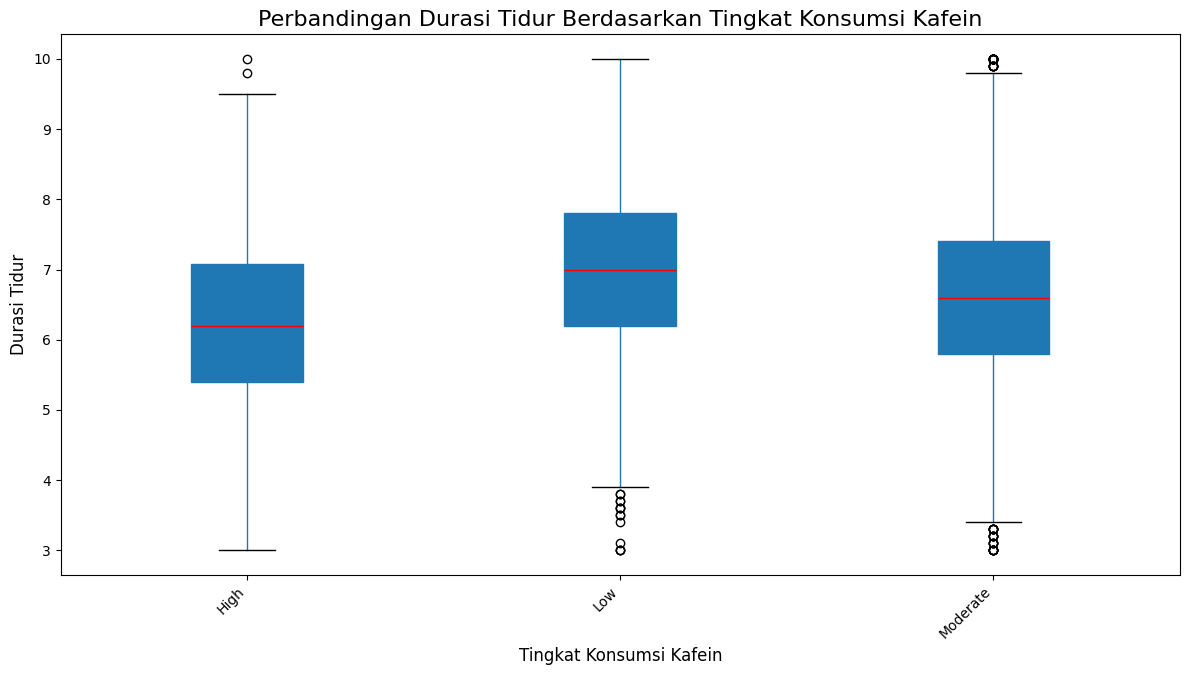

In [160]:
durasi_tidur_berdasarkan_kafein = gd['Caffeine_Level'].value_counts().head(5).index
durasi_tidur_Kafein = gd[gd['Caffeine_Level'].isin(durasi_tidur_berdasarkan_kafein)]

plt.figure(figsize=(12, 7)) # Ukuran figure
durasi_tidur_Kafein.boxplot(column='Sleep_Hours', by='Caffeine_Level', ax=plt.gca(), grid=False, patch_artist=True, medianprops=dict(color='red'))
plt.title('Perbandingan Durasi Tidur Berdasarkan Tingkat Konsumsi Kafein', fontsize=16) # Judul
plt.xlabel('Tingkat Konsumsi Kafein', fontsize=12) # X Keterangan
plt.ylabel('Durasi Tidur', fontsize=12) # Y Keterangan
plt.xticks(rotation=45, ha='right')
plt.suptitle('') # Menghilangkan judul default dari boxplot.by
plt.tight_layout()
plt.show()

###**Insight**  
Box Plot di atas menunjukkan adanya hubungan yang jelas antara tingkat konsumsi kafein dengan durasi tidur harian responden. Kelompok dengan konsumsi kafein rendah (*Low*) memiliki median durasi tidur tertinggi, yaitu sekitar 7 jam, dengan rentang distribusi yang lebih stabil di angka yang sehat. Sebaliknya, kelompok dengan konsumsi kafein tinggi (*High*) memiliki median durasi tidur terendah, yakni sekitar 6 jam, serta menunjukkan variasi data yang cukup lebar. Menariknya, pada kategori Low dan Moderate, terdapat cukup banyak titik outlier di bagian bawah (durasi tidur sangat singkat), yang menandakan bahwa meski asupan kafein rendah, faktor lain tetap menyebabkan beberapa individu mengalami durasi tidur yang kurang.

###**Action**  
Langkah yang perlu dilakukan adalah mengedukasi tentang pembatasan asupan kafein bagi kelompok *High* dan *Moderate* agar durasi tidur mereka dapat meningkat mendekati angka ideal, yaitu 7–8 jam. Menyarankan responden untuk tidak mengonsumsi kafein setelah jam 2 siang juga perlu dilakukan guna meminimalisir gangguan pada siklus tidur. Selain itu, bagi responden yang berada pada titik outlier bawah (yang tidurnya di bawah 4 jam meskipun asupan kafeinnya rendah), disarankan untuk mengikuti pemeriksaan kesehatan lebih lanjut atau manajemen stres, karena masalah tidur mereka kemungkinan besar dipicu oleh faktor di luar konsumsi kafein.

##**ScatterPlot**

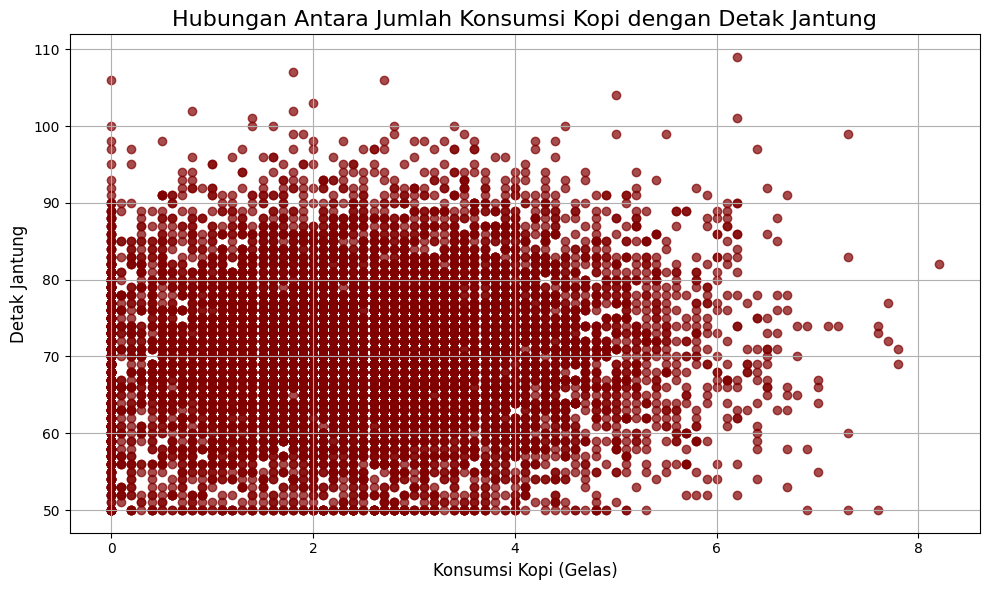

In [161]:
plt.figure(figsize=(10, 6)) # Ukuran
plt.scatter(gd['Coffee_Intake'], gd['Heart_Rate'], alpha=0.7, color='maroon') # Color (Warna)
plt.title('Hubungan Antara Jumlah Konsumsi Kopi dengan Detak Jantung', fontsize=16) # Judul
plt.xlabel('Konsumsi Kopi (Gelas)', fontsize=12) # X Keterangan
plt.ylabel('Detak Jantung', fontsize=12) # Y Keterangan
plt.grid(True)
plt.tight_layout()
plt.show()

###**Insight**  
Scatter Plot di atas menunjukkan sebaran data yang sangat padat pada rentang konsumsi 0 hingga 4 gelas kopi per hari, dengan detak jantung mayoritas responden berada di angka 60 hingga 90 BPM. Secara visual, **tidak terlihat adanya korelasi linear yang kuat**, yang berarti peningkatan konsumsi kopi tidak selalu menyebabkan lonjakan detak jantung secara drastis bagi semua orang. Namun, terdapat data yang menarik pada titik 0 gelas, di mana variasi detak jantung tetap lebar, serta beberapa titik *outliers* di atas 100 BPM yang muncul bahkan pada tingkat konsumsi kopi yang rendah hingga moderat.

###**Action**  
indakan yang perlu dilakukan adalah melakukan pemeriksaan kesehatan lebih lanjut bagi responden yang memiliki detak jantung di atas 100 BPM, terutama bagi mereka yang mengonsumsi sedikit kopi, karena hal tersebut mengindikasikan adanya faktor risiko kesehatan lain di luar kafein. Selain itu, bagi responden yang mengonsumsi lebih dari 6 gelas kopi per hari, disarankan untuk melakukan pengurangan asupan secara bertahap guna menjaga kesehatan dalam jangka panjang.

##**Bubble Chart**

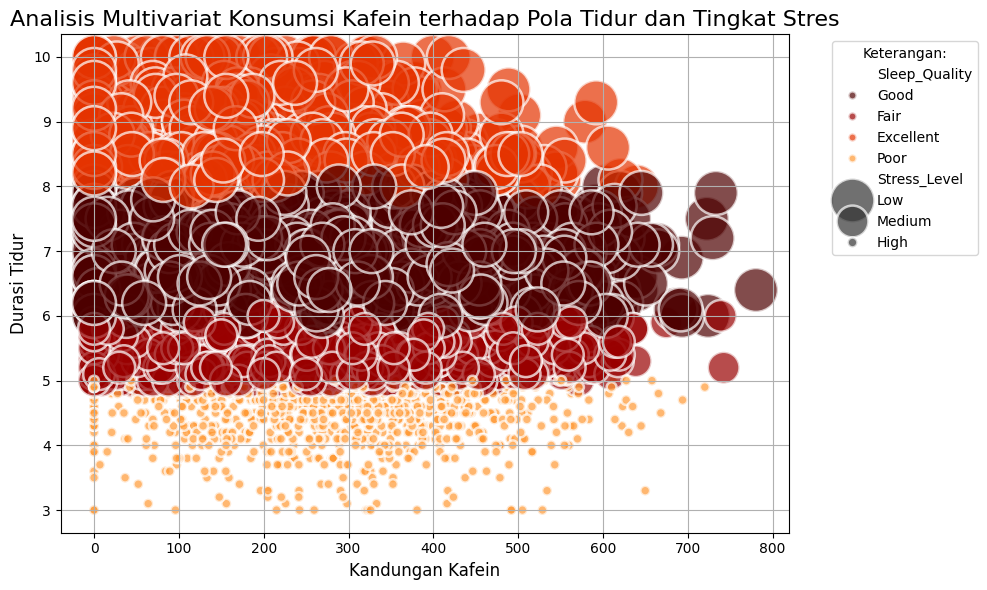

In [162]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Caffeine_mg', y='Sleep_Hours', size='Stress_Level', hue='Sleep_Quality', data=gd, sizes=(50, 1000), alpha=0.7, palette='gist_heat')
plt.title('Analisis Multivariat Konsumsi Kafein terhadap Pola Tidur dan Tingkat Stres', fontsize=16)
plt.xlabel('Kandungan Kafein', fontsize=12)
plt.ylabel('Durasi Tidur', fontsize=12)
plt.grid(True)
plt.legend(title='Keterangan:', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

###**Insight**  
Grafik di atas secara visual memperlihatkan hubungan yang kompleks antara banyaknya kafein yang dikonsumsi dengan jam tidur dan tingkat stres seseorang. Terlihat bahwa responden yang berada di sisi kanan bawah (kafein tinggi dan jam tidur rendah) biasanya memiliki ukuran gelembung yang lebih kecil, yang menandakan tingkat stres yang lebih tinggi. Selain itu, warna gelembung di area tersebut cenderung menunjukkan kualitas tidur yang buruk, mengonfirmasi bahwa konsumsi kafein berlebih tidak hanya memotong durasi tidur tetapi juga merusak kualitas pemulihan tubuh. Sebaliknya, responden dengan asupan kafein rendah hingga moderat cenderung memiliki jam tidur yang normal, kualitas tidur yang baik, dan tingkat stres yang lebih kecil.

###**Action**  
Pengelolaan konsumsi kafein dapat menjadi salah satu langkah yang dipertimbangkan untuk menjaga kualitas tidur dan mengurangi tingkat stres. Individu yang memiliki pola konsumsi kafein tinggi dapat mencoba mengurangi jumlah konsumsi harian atau membatasi konsumsi pada waktu tertentu, misalnya tidak mengonsumsi kafein pada sore hingga malam hari. Selain itu, analisis lanjutan dapat dilakukan untuk melihat faktor lain yang mempengaruhi durasi tidur dan stres, seperti aktivitas harian, pola kerja, atau kebiasaan sebelum tidur, sehingga strategi peningkatan kesehatan tidur dapat dirancang secara lebih komprehensif.

##**Heatmap**

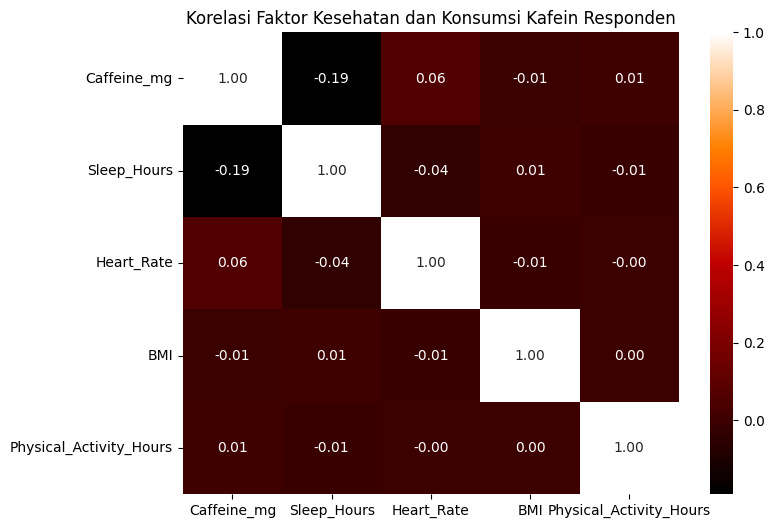

In [163]:
plt.figure(figsize=(8, 6))
sns.heatmap(data=gd[['Caffeine_mg', 'Sleep_Hours', 'Heart_Rate', 'BMI', 'Physical_Activity_Hours']].corr(),
            annot=True,
            cmap='gist_heat',
            fmt='.2f')
plt.title('Korelasi Faktor Kesehatan dan Konsumsi Kafein Responden')
plt.show()

###**Insight**  
Berdasarkan heatmap di atas, tidak ada hubungan yang kuat antara kolom kesehatan dengan konsumsi kafein dalam mg, karena tidak ada korelasi yang mendekati angka 1. Namun, angka hubungan yang paling signifikan terlihat antara konsumsi kafein (Caffeine_mg) dan durasi tidur (Sleep_Hours) dengan nilai korelasi negatif sebesar **-0,19**. Hal ini menunjukkan bahwa peningkatan asupan kafein cenderung diikuti dengan penurunan durasi tidur responden. Sementara itu, variabel lain seperti BMI dan Physical_Activity_Hours menunjukkan korelasi yang mendekati nol terhadap variabel lainnya, yang berarti faktor-faktor tersebut tidak memiliki hubungan linear yang kuat dalam kumpulan data ini. Hubungan antara kafein dan detak jantung (Heart_Rate) juga tergolong lemah (**0,06**), mengindikasikan bahwa konsumsi kafein bukan satu-satunya faktor penentu tinggi atau rendahnya detak jantung pada responden.

###**Action**  
Tindakan yang harus dilakukan karena nilai korelasi antara konsumsi kafein dengan durasi tidur (sama seperti barchart) adalah membatasi minuman berkafein atau kopi di area kerja atau rumah setelah jam makan siang agar tidak mengganggu jadwal tidur malam. Responden dapat mengganti minuman kopi dengan air putih atau minuman tanpa kafein lainnya untuk membantu tubuh lebih rileks saat malam.